In [1]:
import sys
sys.path.append('../')
import imodal
import torch
import matplotlib
import matplotlib.pyplot as plt
import script.generate.divergence_free_curves as data_gen

device = 'cpu'
torch.set_default_device(device)
dtype = torch.float64
torch.set_default_dtype(dtype)
backend = 'torch'
imodal.Utilities.set_compute_backend(backend)

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : OpenMP library not found, it must be downloaded through Homebrew for apple Silicon chips
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


/Users/barbara/Downloads/implicitmodules-clean 2/implicitmodules_clean/script/../imodal/Utilities/sampling.py:59: SyntaxWarning: invalid escape sequence '\s'
  If true, normalise weight values, such that :math:'\alpha_i = \frac{\alpha_i}{\sum_k \alpha_k}'
/Users/barbara/Downloads/implicitmodules-clean 2/implicitmodules_clean/script/../imodal/DeformationModules/Combination.py:96: SyntaxWarning: invalid escape sequence '\d'
  """Computes geodesic control from \delta \in H^\ast."""
/Users/barbara/Downloads/implicitmodules-clean 2/implicitmodules_clean/script/../imodal/Manifolds/Compound.py:74: SyntaxWarning: invalid escape sequence '\*'
  """ Unflattens the list into one suitable for fill_gd() or all \*_gd() numerical operations. """
/Users/barbara/Downloads/implicitmodules-clean 2/implicitmodules_clean/script/../imodal/DeformationModules/ImplicitModule1.py:22: SyntaxWarning: invalid escape sequence '\s'
  |v|^2_V + 1/nu \sum_i  1/2 | Dv(x_i) + Dv(x_i)^T - R_i diag(C[i,:,:] @ h)R_i^T |^2$

In [2]:
col_source = 'dodgerblue'
col_target = 'limegreen'
col_grid = 'black'
alpha_grid = 0.2

In [3]:
#loading data
source, target = data_gen.generate_divfree_data(device, dtype)


In [4]:
# generating control points
aabb_source = imodal.Utilities.AABB.build_from_points(source*1.1)
cp_dist = 0.1
points_grid = aabb_source.fill_uniform_spacing_grid(spacing = cp_dist, device=device, dtype=dtype)
points = imodal.Utilities.usefulfunctions.grid2vec(*points_grid)

/opt/miniconda3/envs/envimodal/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_951ooclnw1/croot/libtorch_1746637517770/work/aten/src/ATen/native/TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


(np.float64(-1.1166437465228074),
 np.float64(1.4380743630022144),
 np.float64(-0.6273530695874354),
 np.float64(0.5826469304125648))

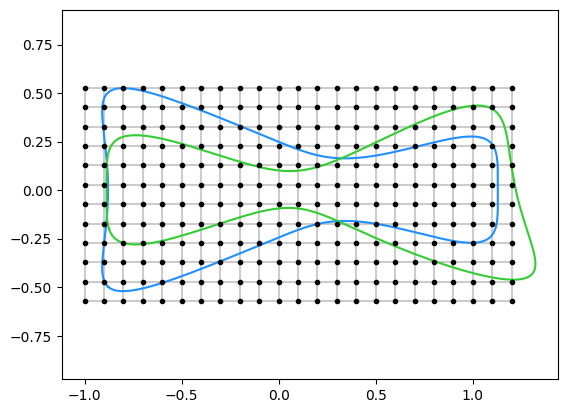

In [5]:
fig, ax = plt.subplots()
imodal.Utilities.plotting.plot_grid(ax, *points_grid, color=col_grid, alpha=alpha_grid)
plt.plot(source[:,0], source[:,1], '-', color=col_source)
plt.plot(target[:,0], target[:,1], '-', color=col_target)
plt.plot(points[:,0], points[:,1], '.', color=col_grid)
plt.axis('equal')

In [6]:
# First registration : Unconstrained 

## Definition of unconstrained IM (generating local translations)
imp0 = imodal.DeformationModules.ImplicitModule0(
    2, points.shape[0],
    sigma=cp_dist*3.,
    coeff=1.,
    nu=1e-5,
    gd=points.clone()
)

## Definition of source and target
deformable_shape_source0 = imodal.Models.DeformablePoints(torch.tensor(source))
deformable_shape_target0 = imodal.Models.DeformablePoints(torch.tensor(target))

## Attachment with multi scale varifolds
varifold_scales = [.5, 1., 2., 5.]
varifold_scales = [scale * cp_dist for scale in varifold_scales]
attach = imodal.Attachment.VarifoldAttachment(2, varifold_scales, backend=backend)

## deformation model
model0 = imodal.Models.RegistrationModel(
    [deformable_shape_source0],
    [imp0],
    [attach],
    lam=10.
)

## Fitting
shoot_it = 10
shoot_solver = 'midpoint'
costs0 = {}
fitter0 = imodal.Models.Fitter(model0, optimizer='torch_lbfgs')
fitter0.fit([deformable_shape_target0],
    20,
    costs=costs0,
    options={
        'shoot_solver': shoot_solver,
        'shoot_it': shoot_it,
        'line_search_fn': 'strong_wolfe'
    }
)



/opt/miniconda3/envs/envimodal/lib/python3.12/site-packages/torch/utils/_device.py:106: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


Starting optimization with method torch LBFGS, using solver midpoint with 10 iterations.
Initial cost={'deformation': 0.0, 'attach': 50.39258490579758}
1e-10


/Users/barbara/Downloads/implicitmodules-clean 2/implicitmodules_clean/script/../imodal/HamiltonianDynamic/hamiltonian.py:39: SyntaxWarning: invalid escape sequence '\m'
  Mathematicaly, computes the quantity :math:`\mathcal{H}(q, p, h)`.
/Users/barbara/Downloads/implicitmodules-clean 2/implicitmodules_clean/script/../imodal/DeformationModules/Combination.py:96: SyntaxWarning: invalid escape sequence '\d'
  """Computes geodesic control from \delta \in H^\ast."""


KeyboardInterrupt: 

In [ ]:
# Computing estimated deformation


intermediates0 = {}
with torch.autograd.no_grad():
    deformed0 = model0.compute_deformed(shoot_solver, shoot_it, intermediates=intermediates0)

## Plotting

rect_indices = []
m0, m1 = points_grid[0].shape
for i in range(m0 - 1):
    for j in range(m1-1):
        rect_indices.append([i*m1+j, i*m1+j+1, (i+1)*m1+j+1, (i+1)*m1+j])

def get_rect_area(rect_idx, coords):
    rect = coords[rect_idx] # shape (4, 2)
    a = rect[0]
    b = rect[1]
    c = rect[2]
    d = rect[3]
    return 0.5 * abs((a[0]*b[1] + b[0]*c[1] + c[0]*d[1] + d[0]*a[1] - b[0]*a[1] - c[0]*b[1] - d[0]*c[1] - a[0]*d[1]))

norm = matplotlib.colors.Normalize(vmin=0.5, vmax=2., clip=True)
cmap = plt.cm.Spectral_r

ratios_imp0 = []

for i, state0 in enumerate(intermediates0['states']):
    fig0, ax0 = plt.subplots(1, 1, figsize=(15, 5), dpi=300)
    for rect in rect_indices:
        original_rect_area = get_rect_area(rect, points)
        rect_area0 = get_rect_area(rect, state0[1].gd)


        ratio0 = rect_area0 / original_rect_area
        ratio0_ = ratio0 if ratio0 < 1. else 1./ratio0 # in 0, 1

        ratios_imp0.append(ratio0.item())

        # plot rectangle in deformed_cp0 with filled color and border
        rectxy0 = (state0[1].gd[rect].cpu())
        ax0.fill(*rectxy0.T, alpha=1, color=cmap(norm(ratio0.item())))
        ax0.plot(*rectxy0.T, 'white', alpha=0.5)

        ax0.axis('equal')
        ax0.set_xticks([])
        ax0.set_yticks([])
        ax0.spines['top'].set_visible(False)
        ax0.spines['right'].set_visible(False)
        ax0.spines['bottom'].set_visible(False)
        ax0.spines['left'].set_visible(False)
    
    # ax.plot(*(state0[0].gd.cpu()+offset_0).T, 'white', alpha=1, linewidth=4, zorder=1000)
    ax0.plot(*(state0[0].gd.cpu()).T, 'crimson', alpha=1, linewidth=4, zorder=1001)

fig, ax = plt.subplots(1, 1, figsize=(6, 1), dpi=200)
ax.axis('off')
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='Spectral_r'), ax=ax, orientation='horizontal', pad=0.01)
cbar.set_ticks([0.5, 1., 2.])


In [ ]:
# Second registration : Divergence free

## Defining deformation module
df = imodal.DeformationModules.ImplicitDivFree(
    2, [points.shape[0], points.shape[0]],
    sigma=cp_dist*3.,
    coeff_div=10000,
    coeff=1.,
    nu=1e-5,
    gd=torch.cat([points, points], dim=0),
    backend=backend
)

## Definition of source and target
deformable_shape_source0 = imodal.Models.DeformablePoints(torch.tensor(source))
deformable_shape_target0 = imodal.Models.DeformablePoints(torch.tensor(target))

## Attachment with multi scale varifolds
varifold_scales = [.5, 1., 2., 5.]
varifold_scales = [scale * cp_dist for scale in varifold_scales]
attach = imodal.Attachment.VarifoldAttachment(2, varifold_scales, backend=backend)

## deformation model
model = imodal.Models.RegistrationModel(
    [deformable_shape_source],
    [df],
    [attach],
    lam=1000., it=shoot_it
)

## Fitting
costs = {}
fitter = imodal.Models.Fitter(model, optimizer='torch_lbfgs')
fitter.fit([deformable_shape_target],
    20,
    costs=costs,
    options={
        'shoot_solver': shoot_solver,
        'shoot_it': shoot_it,
        'line_search_fn': 'strong_wolfe'
    }
)

In [ ]:
# Computing estimated deformation

intermediates = {}
with torch.autograd.no_grad():
    deformed = model.compute_deformed(shoot_solver, shoot_it, intermediates=intermediates)

## Plotting

rect_indices = []
m0, m1 = points_grid[0].shape
for i in range(m0 - 1):
    for j in range(m1-1):
        rect_indices.append([i*m1+j, i*m1+j+1, (i+1)*m1+j+1, (i+1)*m1+j])

def get_rect_area(rect_idx, coords):
    rect = coords[rect_idx] # shape (4, 2)
    a = rect[0]
    b = rect[1]
    c = rect[2]
    d = rect[3]
    return 0.5 * abs((a[0]*b[1] + b[0]*c[1] + c[0]*d[1] + d[0]*a[1] - b[0]*a[1] - c[0]*b[1] - d[0]*c[1] - a[0]*d[1]))

norm = matplotlib.colors.Normalize(vmin=0.5, vmax=2., clip=True)
cmap = plt.cm.Spectral_r

ratios_df = []

for i, state in enumerate(intermediates['states']):
    fig, ax = plt.subplots(1, 1, figsize=(15, 5), dpi=300)
    for rect in rect_indices:
        original_rect_area = get_rect_area(rect, points)
        rect_area = get_rect_area(rect, state[1].gd)

        ratio = rect_area / original_rect_area
        ratio_ = ratio if ratio < 1. else 1./ratio # in 0, 1

        ratios_df.append(ratio.item())
        
        # plot rectangle in deformed_cp with filled color and border
        rectxy = state[1].gd[rect].cpu()
        ax.fill(*rectxy.T, alpha=1, color=cmap(norm(ratio.item())))
        ax.plot(*rectxy.T, 'white', alpha=0.5)

        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)

    # ax.plot(*state[0].gd.cpu().T, 'white', alpha=1, linewidth=4, zorder=1000)
    ax.plot(*state[0].gd.cpu().T, 'crimson', alpha=1, linewidth=4, zorder=1001)


fig, ax = plt.subplots(1, 1, figsize=(6, 1), dpi=200)
ax.axis('off')
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='Spectral_r'), ax=ax, orientation='horizontal', pad=0.01)
cbar.set_ticks([0.5, 1., 2.])

